# Data Preprocessing
This notebook starts with downloading the dataset and then performs data preprocessing steps to create a clean dataset for further analysis.

## Imports

In [1]:
from tqdm import tqdm
import csv
import pandas as pd
import csv
import ahocorasick
import math
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Dowloaded and extracted Stuttgart 0.88 B Version of SDEWAC German Corpus and renamed from .tagged to .txt
data_path = "data/sdewac-v3.txt" 

## Take 10k Sentences of the dataset (only run if you want to test the code with a smaller dataset)

In [ ]:
sentences_count = 10000
output_path = f"data/sdewac-v3_{sentences_count}.txt"
sentence_counter = 0

with open(data_path, "r", encoding="utf-8") as f_in, \
     open(output_path, "w", encoding="utf-8") as f_out:
    
    for line in f_in:
        f_out.write(line)
        if "</sentence>" in line:
            sentence_counter += 1
            if sentence_counter >= sentences_count:
                break

print(f"Saved first {sentence_counter} sentences to: {output_path}")
data_path = output_path


## Calculate Corpus Wide Metrics for each Keyword

In [ ]:
total_lines = sum(1 for _ in open(data_path, encoding="utf-8"))
print(f"Total lines in {data_path}: {total_lines}")

# ─── CONFIG ────────────────────────────────────────────────────────────────
keywords_csv    = "keyword_groundtruth.csv"
output_csv      = "keywords_metrics.csv"
#datapath is set above
# ──────────────────────────────────────────────────────────────────────────

# 1) Read & normalize keyword variants **and** ground-truth score
keyword_variants = []
score_map        = {}  # key → gramm_score
with open(keywords_csv, encoding="utf-8") as f:
    reader = csv.reader(f)
    next(reader)  # skip header: keyword,score
    for row in reader:
        kw, score = row[0].strip(), row[1].strip()
        if not kw:
            continue
        variants = [v.lower() for v in kw.split('/') if v.strip()]
        if not variants:
            continue
        key = "/".join(variants)
        keyword_variants.append(variants)
        score_map[key] = float(score)  # oder int(score) je nach Bedarf

# Build a map from each variant ➔ its “group key”
variant_to_key = {}
for variants in keyword_variants:
    key = "/".join(variants)
    for v in variants:
        variant_to_key[v] = key

# 2) Build Aho–Corasick automaton (all lowercase)
A = ahocorasick.Automaton()
for v, key in variant_to_key.items():
    A.add_word(v, key)
A.make_automaton()

# 3) Prepare accumulators
freq           = {key: 0 for key in variant_to_key.values()}
contexts       = {key: []    for key in variant_to_key.values()}
pre_tags       = {key: set() for key in variant_to_key.values()}
post_tags      = {key: set() for key in variant_to_key.values()}
token_counts   = {}     # total token frequencies
bigram_counts  = {}     # (key, neighbor) frequencies
total_tokens   = 0

# 4) First pass: collect tokens, POS, track keyword occurrences + contexts
#    We need a sliding window, so we buffer the last token, tag.
prev_tok, prev_tag = None, None

with open(data_path, encoding="utf-8") as f:
    for line in tqdm(f, total=total_lines, desc="Scanning tokens"):
        line = line.rstrip()
        # skip sentence markers & metadata
        if not line or line.startswith("<"):
            continue

        # token, POS, _ = token[TAB] POS[TAB] rest…
        parts = line.split("\t")
        if len(parts) < 2:
            continue
        tok  = parts[0].lower()
        tag  = parts[1]
        total_tokens += 1
        token_counts[tok] = token_counts.get(tok, 0) + 1

        # check for keyword matches on this single token
        for _, key in A.iter(tok):
            freq[key] += 1

            # record context word for entropy / collocations
            #  — previous token
            if prev_tok is not None:
                contexts[key].append(prev_tok)
                bigram_counts[(key, prev_tok)] = bigram_counts.get((key, prev_tok), 0) + 1
                pre_tags[key].add(prev_tag)
            #  — we’ll handle next token in the next iteration
        # Now that we’ve processed tok, set up for post-context of the *last* keyword
        # Actually easier to do two passes. Instead, buffer all sentence tokens… 
        # But for simplicity, we can collect "post" by remembering which keys matched *last* token.
        # We'll do a second pass to fill post_tags and contexts[key] with next token.

        prev_tok, prev_tag = tok, tag

# 5) Second pass for post-context (almost identical to above, but shifted)
#    We’ll reset buffer and look ahead for each keyword occurrence:
prev_tok, prev_tag = None, None
with open(data_path, encoding="utf-8") as f:
    for line in tqdm(f, total=total_lines, desc="Scanning post-contexts"):
        line = line.rstrip()
        if not line or line.startswith("<"):
            continue
        parts = line.split("\t")
        if len(parts) < 2:
            continue
        tok, tag = parts[0].lower(), parts[1]

        # if prev_tok was a keyword, this tok is its post-context
        for _, key in A.iter(prev_tok or ""):
            contexts[key].append(tok)
            bigram_counts[(key, tok)] = bigram_counts.get((key, tok), 0) + 1
            post_tags[key].add(tag)

        prev_tok, prev_tag = tok, tag

# 6) Compute total bigrams ≈ total_tokens-1
total_bigrams = max(total_tokens - 1, 1)

# 7) Build metrics per key
rows = []
max_occ = max(freq.values())
min_occ = min(freq.values())
occ_range = max_occ - min_occ or 1
for variants in keyword_variants:
    key = "/".join(variants)
    k_freq = freq[key]
    # normalized occurrence
    norm_occ = (1.0 if k_freq == max_occ else
                0.0 if k_freq == min_occ else
                (k_freq - min_occ)/occ_range)

    # avg. length of variants
    lengths = [len(v) for v in variants]
    avg_len = sum(lengths)/len(lengths)

    # context_entropy ≈ # distinct context words
    ctx_ent = len(set(contexts[key]))

    # synthetic context adversity = # distinct pre-POS + post-POS
    sca = len(pre_tags[key]) + len(post_tags[key])

    # collocation_strength ≈ PMI averaged over all collocates
    #   PMI(w,c) = log2( P(w,c) / P(w)*P(c) )
    #   P(w,c) ≈ bigram_counts[(w,c)] / total_bigrams
    #   P(w)   = freq[w] / total_tokens
    #   P(c)   = token_counts[c] / total_tokens
    weighted_pmi_sum = 0.0
    for (w,c), bc in bigram_counts.items():
        if w != key: continue
        p_wc = bc / total_bigrams
        p_w  = k_freq / total_tokens if k_freq>0 else 1/total_tokens
        p_c  = token_counts.get(c,1) / total_tokens
        pmi = math.log2(p_wc / (p_w * p_c) + 1e-12)
        weighted_pmi_sum += pmi * bc
    col_str = weighted_pmi_sum / k_freq if k_freq>0 else 0.0
    gramm_score = score_map.get(key, None)

    rows.append({
        "keyword": key,
        "occurrences": k_freq,
        "normalized_occurrences": norm_occ,
        "avg_length": avg_len,
        "context_entropy": ctx_ent,
        "collocation_strength": col_str,
        "synthetic_context_adversity": sca,
        "gramm_score": gramm_score  # hier hinfügen
    })

# 8) Dump to CSV (inkl. gramm_score)
df = pd.DataFrame(rows).sort_values("occurrences", ascending=False)
df.to_csv(output_csv, index=False)
print(f"Wrote {len(df)} rows (incl. gramm_score) to {output_csv}")

## Analyse Keyword Metrics

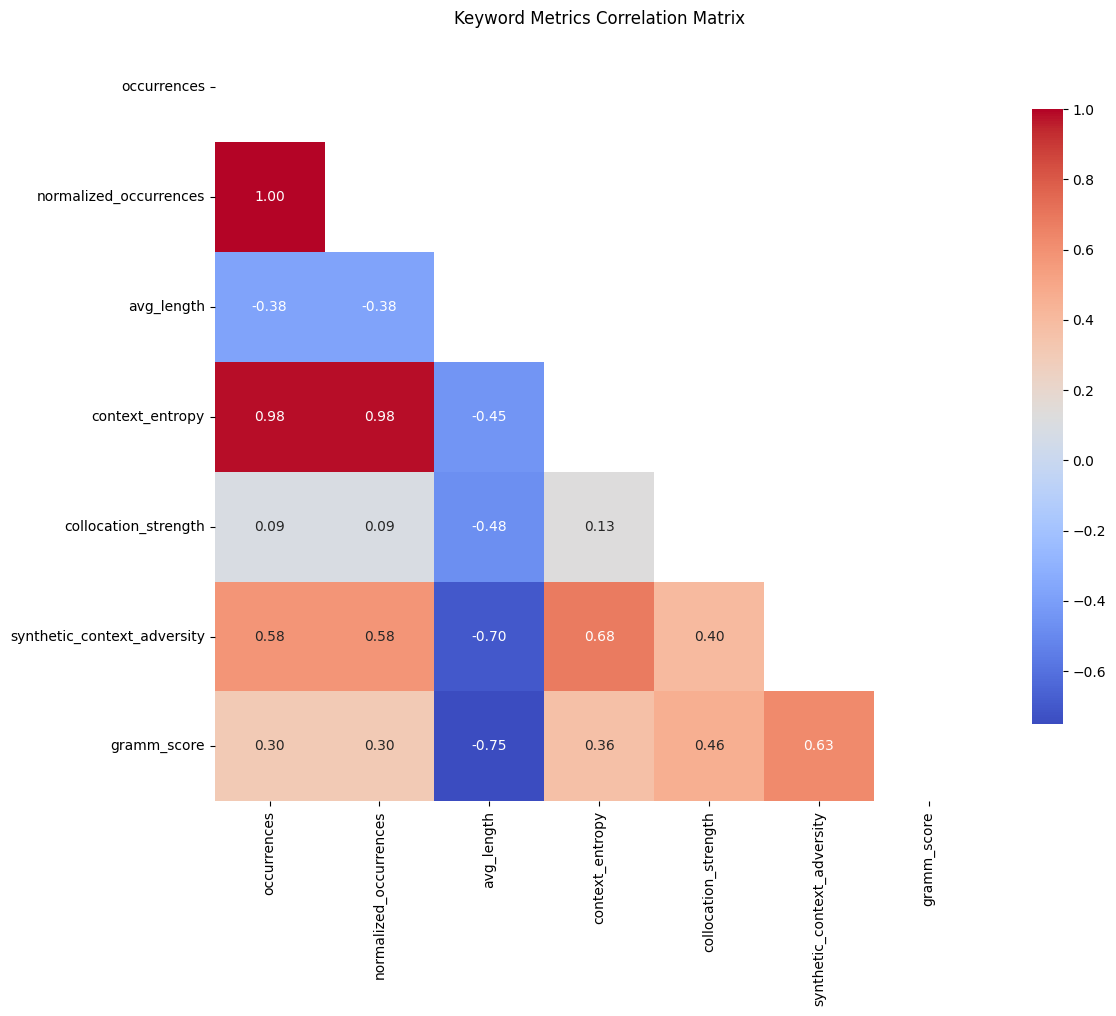

In [3]:
path = "keywords_metrics.csv"
df = pd.read_csv(path)

corr_matrix = df.drop(columns=["keyword"]).corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True, 
            cbar_kws={"shrink": .8}, mask=mask)
plt.title("Keyword Metrics Correlation Matrix")
plt.tight_layout()
plt.show()
